<div style="background-color:#21295C; color:white; padding:30px; border-radius:8px;">
<h1 style="margin-top:0;">Logística × Satisfação</h1>
<p style="font-size:18px; font-style:italic;">O que pesa mais na nota do cliente: o atraso ou o frete?</p>
<hr style="border-color:#1C7293;">
<p><b>Disciplina:</b> Probabilidade e Estatística<br>
<b>Base de dados:</b> Olist — marketplace brasileiro real<br>
<b>Grupo:</b> Cauan, Ricardo, Diego, Victor, Camila e Daniel</p>
</div>

## O Problema de Negócio
> "Como o valor do frete e o tempo de entrega impactam a nota de avaliação dos consumidores em diferentes regiões do Brasil?"

<div style="background-color:#1C7293; color:white; padding:10px 20px; border-radius:6px; font-size:16px; margin-top:20px;">
<b>Seção 1 — Preparação e Ingestão dos Dados</b>
</div>

Para investigar essa relação, precisamos cruzar informações que estão em tabelas separadas. Utilizaremos o método de união (Left Join) para consolidar cinco bases: Orders, Items, Reviews, Customers e Products.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv("Dataset/olist_orders_dataset.csv")
order_items = pd.read_csv("Dataset/olist_order_items_dataset.csv")
order_reviews = pd.read_csv("Dataset/olist_order_reviews_dataset.csv")
customers = pd.read_csv("Dataset/olist_customers_dataset.csv")
products = pd.read_csv("Dataset/olist_products_dataset.csv")

def definir_categoria(series):
    series_limpa = series.dropna()
    if series_limpa.empty:
        return 'Sem Categoria'
    return series_limpa.iloc[0] if series.nunique() == 1 else 'Múltiplas Categorias'

# order_items tem 1 linha por produto: agrega para o grao "pedido" antes do merge.
# freight_value e price sao por item -> soma; senao o frete do carrinho fica subestimado
# e pedidos com >1 produto viram linhas duplicadas.
# Merge com products antes do groupby por order_id para atribuir a categoria_final de forma segura.
itens_por_pedido = (
    order_items
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .groupby("order_id")
    .agg(
        freight_value=("freight_value", "sum"),
        valor_produtos=("price", "sum"),
        qtd_itens=("order_item_id", "count"),
        categoria_final=("product_category_name", definir_categoria),
    )
    .reset_index()
)

# 1 pedido pode ter mais de uma review -> mantem apenas a mais recente.
reviews_por_pedido = (
    order_reviews
    .sort_values("review_creation_date")
    .drop_duplicates(subset="order_id", keep="last")
)

df_merged = (
    orders
    .merge(itens_por_pedido, on="order_id", how="left")
    .merge(reviews_por_pedido, on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
)

# grao esperado: 1 linha por pedido
assert len(df_merged) == len(orders), f"esperado {len(orders)} pedidos, veio {len(df_merged)}"
df_merged.shape

(99441, 22)

In [3]:
# Checagem de valores ausentes pos-merge (higiene basica de EDA).
# Pedidos sem item, sem review ou sem entrega aparecem como NaN aqui.
faltantes = df_merged.isna().sum()
print(faltantes[faltantes > 0])

order_approved_at                  160
order_delivered_carrier_date      1783
order_delivered_customer_date     2965
freight_value                      775
valor_produtos                     775
qtd_itens                          775
categoria_final                    775
review_id                          768
review_score                       768
review_comment_title             87889
review_comment_message           58665
review_creation_date               768
review_answer_timestamp            768
dtype: int64


<div style="background-color:#1C7293; color:white; padding:10px 20px; border-radius:6px; font-size:16px;">
<b>Seção 2 — Engenharia de Recursos (Feature Engineering)</b>
</div>

A base original nos fornece apenas os timestamps brutas. Para aplicarmos as técnicas estatísticas, precisamos transformar essas datas em uma variável quantitativa contínua. O código abaixo cria a variável tempo_entrega_dias, investiga os pedidos não entregues (diagnóstico de sobrevivência) e isola apenas os pedidos entregues para análise de tempo.

In [4]:
df_merged["order_purchase_timestamp"] = pd.to_datetime(df_merged["order_purchase_timestamp"])
df_merged["order_delivered_customer_date"] = pd.to_datetime(df_merged["order_delivered_customer_date"])

df_merged["tempo_entrega_dias"] = (
    df_merged["order_delivered_customer_date"] - df_merged["order_purchase_timestamp"]
).dt.days

**Atenção (limitação metodológica - H2):** o filtro abaixo remove pedidos sem `tempo_entrega_dias`, ou seja, pedidos cancelados ou nunca entregues. Esses são provavelmente os pedidos com as piores notas (ex: "nunca recebi o produto"). Ao excluí-los antes de estudar a relação entrega×nota, a análise pode estar **subestimando** a força da associação entre logística e satisfação (viés de sobrevivência). Abaixo investigamos o diagnóstico dessas falhas por estado antes de filtrar.

In [5]:
pedidos_sem_entrega = df_merged[df_merged["order_delivered_customer_date"].isnull()]
diagnostico_falhas = pedidos_sem_entrega.groupby(["customer_state", "order_status"]).size().reset_index(name="qtd_pedidos")
total_por_estado = df_merged.groupby("customer_state").size()
diagnostico_falhas["taxa_falha_pct"] = diagnostico_falhas.apply(
    lambda row: (row["qtd_pedidos"] / total_por_estado[row["customer_state"]]) * 100, axis=1
)
diagnostico_falhas["total_pedidos_estado"] = diagnostico_falhas["customer_state"].map(total_por_estado)
print("Top 10 estados com maiores taxas de pedidos não entregues:")
print(diagnostico_falhas.sort_values("taxa_falha_pct", ascending=False).head(10))

n_antes = len(orders)
n_descartados = len(pedidos_sem_entrega)
print(f"\nPedidos totais: {n_antes}")
print(f"Pedidos descartados (sem entrega registrada): {n_descartados} ({n_descartados / n_antes:.1%})")

Top 10 estados com maiores taxas de pedidos não entregues:
    customer_state order_status  qtd_pedidos  taxa_falha_pct  \
95              RR      shipped            4        8.695652   
17              CE      shipped           38        2.844311   
110             SE      shipped            9        2.571429   
37              MA      shipped           17        2.275770   
85              RJ      shipped          289        2.248677   
4               AL      shipped            9        2.179177   
94              RR     canceled            1        2.173913   
68              PE      shipped           35        2.118644   
63              PB      shipped           11        2.052239   
12              BA      shipped           68        2.011834   

     total_pedidos_estado  
95                     46  
17                   1336  
110                   350  
37                    747  
85                  12852  
4                     413  
94                     46  
68          

In [6]:
df_merged = df_merged[df_merged["tempo_entrega_dias"].notna()]
df_merged[["order_purchase_timestamp", "order_delivered_customer_date", "tempo_entrega_dias"]].head()

,order_purchase_timestamp,order_delivered_customer_date,tempo_entrega_dias
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0


<div style="background-color:#1C7293; color:white; padding:10px 20px; border-radius:6px; font-size:16px;">
<b>Seção 3 — Estatística Descritiva</b>
</div>

Aplicaremos os fundamentos para entender o comportamento logístico:
* **Posição:** Média e Mediana para assimetria.
* **Dispersão:** Desvio Padrão e Amplitude.
* **Outliers:** Intervalo Interquartil (IQR = Q3 - Q1). Entregas acima do Limite Superior são anomalias.

> Ressalva sobre `freight_value`: a distribuição é fortemente assimétrica à direita (média ≫ mediana, cauda até ~R$1.800). Nesse caso o IQR×1,5 na escala bruta marca ~10% da base como "outlier" — isso reflete a assimetria, não anomalias reais. Um limiar de negócio ou uma transformação log seriam mais adequados para essa variável.

In [7]:
for col in ["tempo_entrega_dias", "freight_value"]:
    s = df_merged[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    print(f"=== {col} ===")
    print("Medidas de Posicao")
    print(f"  Media   : {s.mean():.2f}")
    print(f"  Mediana : {s.median():.2f}")
    print("Medidas de Dispersao")
    print(f"  Desvio Padrao : {s.std():.2f}")
    print(f"  Amplitude     : {s.max() - s.min():.2f}  (min={s.min():.2f}, max={s.max():.2f})")
    print("Outliers (metodo IQR)")
    print(f"  Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")
    print(f"  Limite inferior : {lim_inf:.2f}")
    print(f"  Limite superior : {lim_sup:.2f}")
    n_outliers = (s > lim_sup).sum()
    print(f"  Qtd outliers (acima do limite sup.) : {n_outliers} ({n_outliers / len(s):.1%})")
    print()

=== tempo_entrega_dias ===
Medidas de Posicao
  Media   : 12.09
  Mediana : 10.00
Medidas de Dispersao
  Desvio Padrao : 9.55
  Amplitude     : 209.00  (min=0.00, max=209.00)
Outliers (metodo IQR)
  Q1=6.00  Q3=15.00  IQR=9.00
  Limite inferior : -7.50
  Limite superior : 28.50
  Qtd outliers (acima do limite sup.) : 5025 (5.2%)

=== freight_value ===
Medidas de Posicao
  Media   : 22.79
  Mediana : 17.17
Medidas de Dispersao
  Desvio Padrao : 21.56
  Amplitude     : 1794.96  (min=0.00, max=1794.96)
Outliers (metodo IQR)
  Q1=13.85  Q3=24.02  IQR=10.17
  Limite inferior : -1.40
  Limite superior : 39.27
  Qtd outliers (acima do limite sup.) : 9694 (10.0%)



<div style="background-color:#1C7293; color:white; padding:10px 20px; border-radius:6px; font-size:16px;">
<b>Seção 4 — Comprovação Visual da Hipótese</b>
</div>

Plotaremos três gráficos lado a lado:
1. **Histograma:** Assimetria e cauda longa do tempo de entrega.
2. **Boxplot:** Dispersão do tempo de entrega vs. Nota de Avaliação.
3. **Barplot:** Custo médio do frete, evidenciando disparidades regionais.

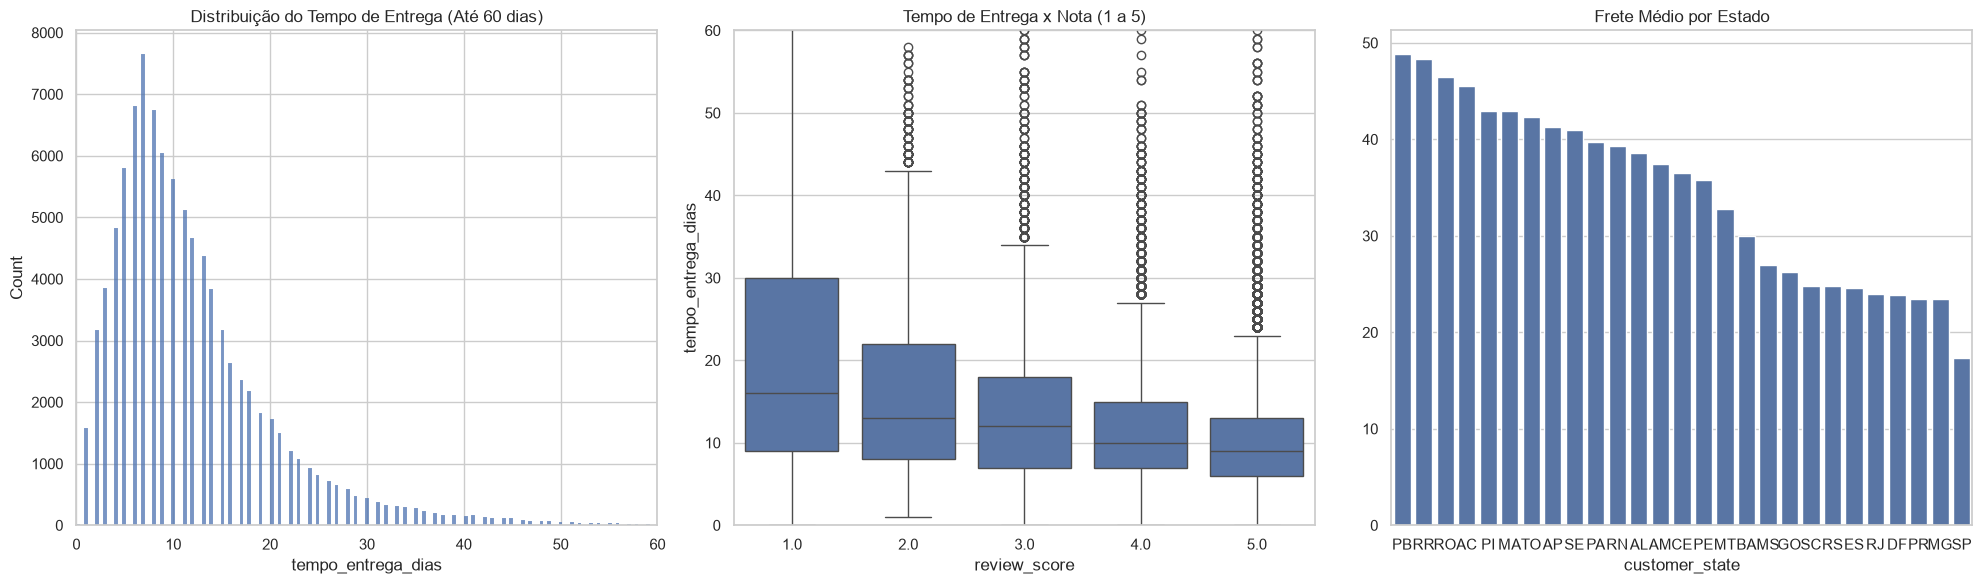

In [8]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(data=df_merged, x="tempo_entrega_dias", ax=axes[0])
axes[0].set_xlim(0, 60)
axes[0].set_title("Distribuição do Tempo de Entrega (Até 60 dias)")

sns.boxplot(data=df_merged, x="review_score", y="tempo_entrega_dias", ax=axes[1])
axes[1].set_ylim(0, 60)
axes[1].set_title("Tempo de Entrega x Nota (1 a 5)")

frete_estado = (
    df_merged.groupby("customer_state")["freight_value"].mean().sort_values(ascending=False)
)
sns.barplot(x=frete_estado.index, y=frete_estado.values, ax=axes[2])
axes[2].set_title("Frete Médio por Estado")

plt.tight_layout()

<div style="background-color:#1C7293; color:white; padding:10px 20px; border-radius:6px; font-size:16px;">
<b>Seção 4.5 — Distribuição das Notas e Relação Frete × Nota</b>
</div>

A hipótese inicial cita tempo de entrega **e** valor do frete como possíveis causas da insatisfação. A seção 4 testou apenas tempo de entrega contra a nota. Aqui fechamos a lacuna: tabela de frequência da própria nota, e o frete testado diretamente contra a nota.

_Nota: a tabela de frequência abaixo usa `value_counts(normalize=True)`, que descarta 646 pedidos entregues sem avaliação. Os percentuais são sobre quem avaliou, não sobre o total de `df_merged`._

Distribuição das notas (%):
review_score
1.0     9.8
2.0     3.0
3.0     8.3
4.0    19.7
5.0    59.2
Name: proportion, dtype: float64


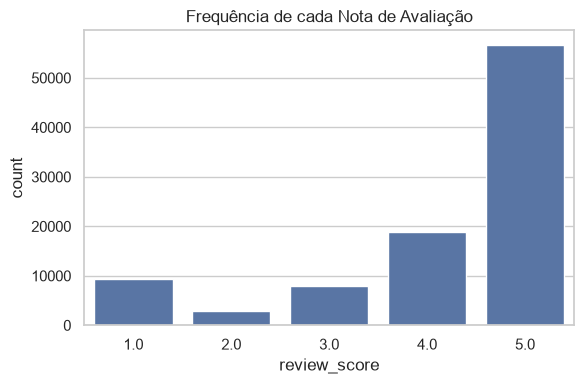

In [9]:
freq_notas = df_merged["review_score"].value_counts(normalize=True).sort_index()
print("Distribuição das notas (%):")
print((freq_notas * 100).round(1))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_merged, x="review_score", ax=ax)
ax.set_title("Frequência de cada Nota de Avaliação")
plt.tight_layout()

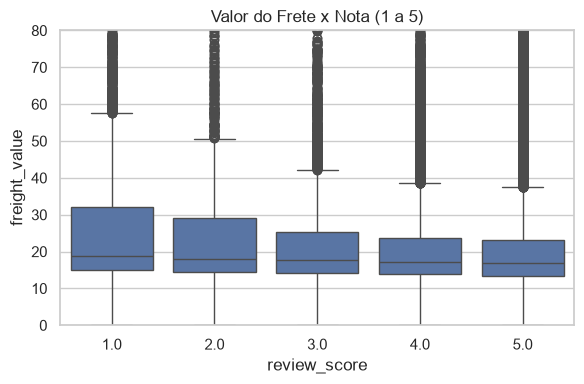

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df_merged, x="review_score", y="freight_value", ax=ax)
ax.set_ylim(0, 80)
ax.set_title("Valor do Frete x Nota (1 a 5)")
plt.tight_layout()

In [11]:
print("Mediana do tempo de entrega por nota:")
print(df_merged.groupby('review_score')['tempo_entrega_dias'].median())
print("\nMediana do frete por nota:")
print(df_merged.groupby('review_score')['freight_value'].median())

Mediana do tempo de entrega por nota:
review_score
1.0    16.0
2.0    13.0
3.0    12.0
4.0    10.0
5.0     9.0
Name: tempo_entrega_dias, dtype: float64

Mediana do frete por nota:
review_score
1.0    18.760
2.0    18.025
3.0    17.630
4.0    17.190
5.0    16.790
Name: freight_value, dtype: float64


In [12]:
from scipy.stats import spearmanr
df_corr = df_merged.dropna(subset=['tempo_entrega_dias', 'freight_value', 'review_score'])
corr_frete, _ = spearmanr(df_corr['freight_value'], df_corr['review_score'])
corr_tempo, _ = spearmanr(df_corr['tempo_entrega_dias'], df_corr['review_score'])
corr_frete_tempo, _ = spearmanr(df_corr['freight_value'], df_corr['tempo_entrega_dias'])
print(f"Amostra: {len(df_corr)} pedidos")
print(f"Spearman Frete x Nota: {corr_frete:.3f}")
print(f"Spearman Tempo x Nota: {corr_tempo:.3f}")
print(f"Spearman Frete x Tempo (multicolinearidade): {corr_frete_tempo:.3f}")

Amostra: 95830 pedidos
Spearman Frete x Nota: -0.088
Spearman Tempo x Nota: -0.235
Spearman Frete x Tempo (multicolinearidade): 0.381


<div style="background-color:#1C7293; color:white; padding:10px 20px; border-radius:6px; font-size:16px;">
<b>Seção 4.6 — Teste de Hipótese 3: Categoria do Produto × Atraso × Nota (H3)</b>
</div>

Avaliamos se a sensibilidade ao atraso varia de acordo com a categoria do produto (excluindo pedidos com itens de múltiplas categorias para evitar ruído). O limiar de atraso utilizado é o limite superior IQR (28.5 dias) calculado na seção 3.

In [13]:
df_h3 = df_merged[df_merged['categoria_final'] != 'Múltiplas Categorias'].copy()
df_h3['atrasado'] = df_h3['tempo_entrega_dias'] > 28.5  # limite IQR já calculado na seção 3
resultado_h3 = (
    df_h3[df_h3['atrasado']]
    .groupby('categoria_final')['review_score']
    .agg(['mean', 'count'])
    .sort_values('mean')
)
resultado_h3_filtrado = resultado_h3[resultado_h3['count'] >= 30]
print("Nota média entre pedidos ATRASADOS, por categoria (mín. 30 pedidos):")
print(resultado_h3_filtrado.head(10))
print("\nPiores casos:")
print(resultado_h3_filtrado.tail(10))

Nota média entre pedidos ATRASADOS, por categoria (mín. 30 pedidos):
                                       mean  count
categoria_final                                   
instrumentos_musicais              2.029412     34
fashion_bolsas_e_acessorios        2.054054     74
construcao_ferramentas_construcao  2.096774     31
cama_mesa_banho                    2.154989    471
Sem Categoria                      2.159420     69
eletronicos                        2.171875    128
bebes                              2.231214    173
brinquedos                         2.239766    171
pet_shop                           2.245614     57
esporte_lazer                      2.245810    358

Piores casos:
                            mean  count
categoria_final                        
automotivo              2.306533    199
informatica_acessorios  2.307246    345
beleza_saude            2.356828    454
relogios_presentes      2.404459    314
cool_stuff              2.453333    150
perfumaria              

<div style="background-color:#1C7293; color:white; padding:10px 20px; border-radius:6px; font-size:16px;">
<b>Seção 5 — Conclusões e Insights</b>
</div>

1. **A média engana:** O desvio padrão alto e a diferença entre Média e Mediana indicam forte assimetria e inconstância no tempo de entrega.
2. **Atraso está associado a notas baixas:** O Boxplot mostra que avaliações 1 e 2 estão associadas a caixas (IQR) e medianas de tempo de entrega mais altas. É uma associação observada, não uma relação causal comprovada.
3. **Barreira geográfica (H2):** Estados do Norte e Nordeste estão associados a fretes médios por pedido mais altos e maiores taxas de pedidos não entregues — Ceará, Sergipe e Maranhão se destacam com volume de pedidos suficiente para confiança estatística. Roraima aparece com a maior taxa nominal (8,7%), mas com apenas 46 pedidos totais no estado, o que exige cautela antes de generalizar esse número.
4. **Frete x nota e Correlação de Spearman (H1):** O teste de Spearman confirma correlação negativa moderada entre tempo de entrega e nota (-0.235), enquanto frete x nota apresenta correlação fraca (-0.088). Há multicolinearidade moderada entre frete e tempo (0.381). O gargalo logístico dominante na satisfação é o prazo de entrega.
5. **Sensibilidade por categoria ao atraso (H3):** Quando ocorrem atrasos críticos (> 28.5 dias), categorias como *instrumentos_musicais*, *fashion_bolsas_e_acessorios* e *construcao_ferramentas_construcao* sofrem maior penalização na nota média (~2.0 a 2.1), comparadas a categorias mais tolerantes como *moveis_escritorio* (2.84).

> Observação: a análise é exploratória. As relações acima são associações; estabelecer causalidade exigiria controle de outras variáveis (distância, categoria do produto, sazonalidade). Além disso, a base usada nas seções 3-4.6 exclui pedidos nunca entregues (ver nota de viés de sobrevivência na seção 2), o que pode subestimar o efeito real da logística na satisfação.

<div style="background-color:#21295C; color:white; padding:30px; border-radius:8px;">
<h2 style="margin-top:0;">Recomendação de Negócio</h2>
<p>Não recomendamos subsidiar frete nacionalmente — a associação frete×nota é fraca. Recomendamos parcerias com transportadoras regionais no Norte/Nordeste e um gatilho automático de cupom/estorno quando o pedido cruzar o limite superior do IQR (28,5 dias).</p>
<hr style="border-color:#1C7293;">
<p style="font-style:italic;">Obrigado — perguntas?</p>
</div>